In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from ml_enhance import FeatureImportance
from collections import defaultdict
from pathlib import Path
import numpy as np
import json

In [4]:
df_baseline = pd.read_csv(r"..\data\chemprop_results\1_chemprop_no_added_w_charge_rerun_SHAP_results.csv")
df_full = pd.read_csv(r"..\data\chemprop_results\1_chemprop_full_feat_rerun_SHAP_results.csv")
df_rdkit = pd.read_csv(r"..\data\chemprop_results\1_chemprop_w_rdkit_rerun_SHAP_results.csv")
df_mol = pd.read_csv(r"..\data\chemprop_results\1_chemprop_mol_feat_rerun_SHAP_results.csv")

In [5]:
drop_formal_charge = True
frequency: dict[str, int] = defaultdict(int)
importance_dict: dict[str, list[float]] = defaultdict(list)

In [6]:
importance_baseline = FeatureImportance(df_baseline)
fi_df_base = importance_baseline.get_FI_from_shap(drop_formal_charge=False, num_features=30)

importance_full = FeatureImportance(df_full)
fi_df_full = importance_full.get_FI_from_shap(drop_formal_charge=True, num_features=30)

importance_rdkit = FeatureImportance(df_rdkit)
_ = importance_rdkit.get_FI_from_shap(drop_formal_charge=True, num_features=30)

importance_mol = FeatureImportance(df_mol)
_ = importance_mol.get_FI_from_shap(drop_formal_charge=True, num_features=30)

In [7]:
n_feat = 10

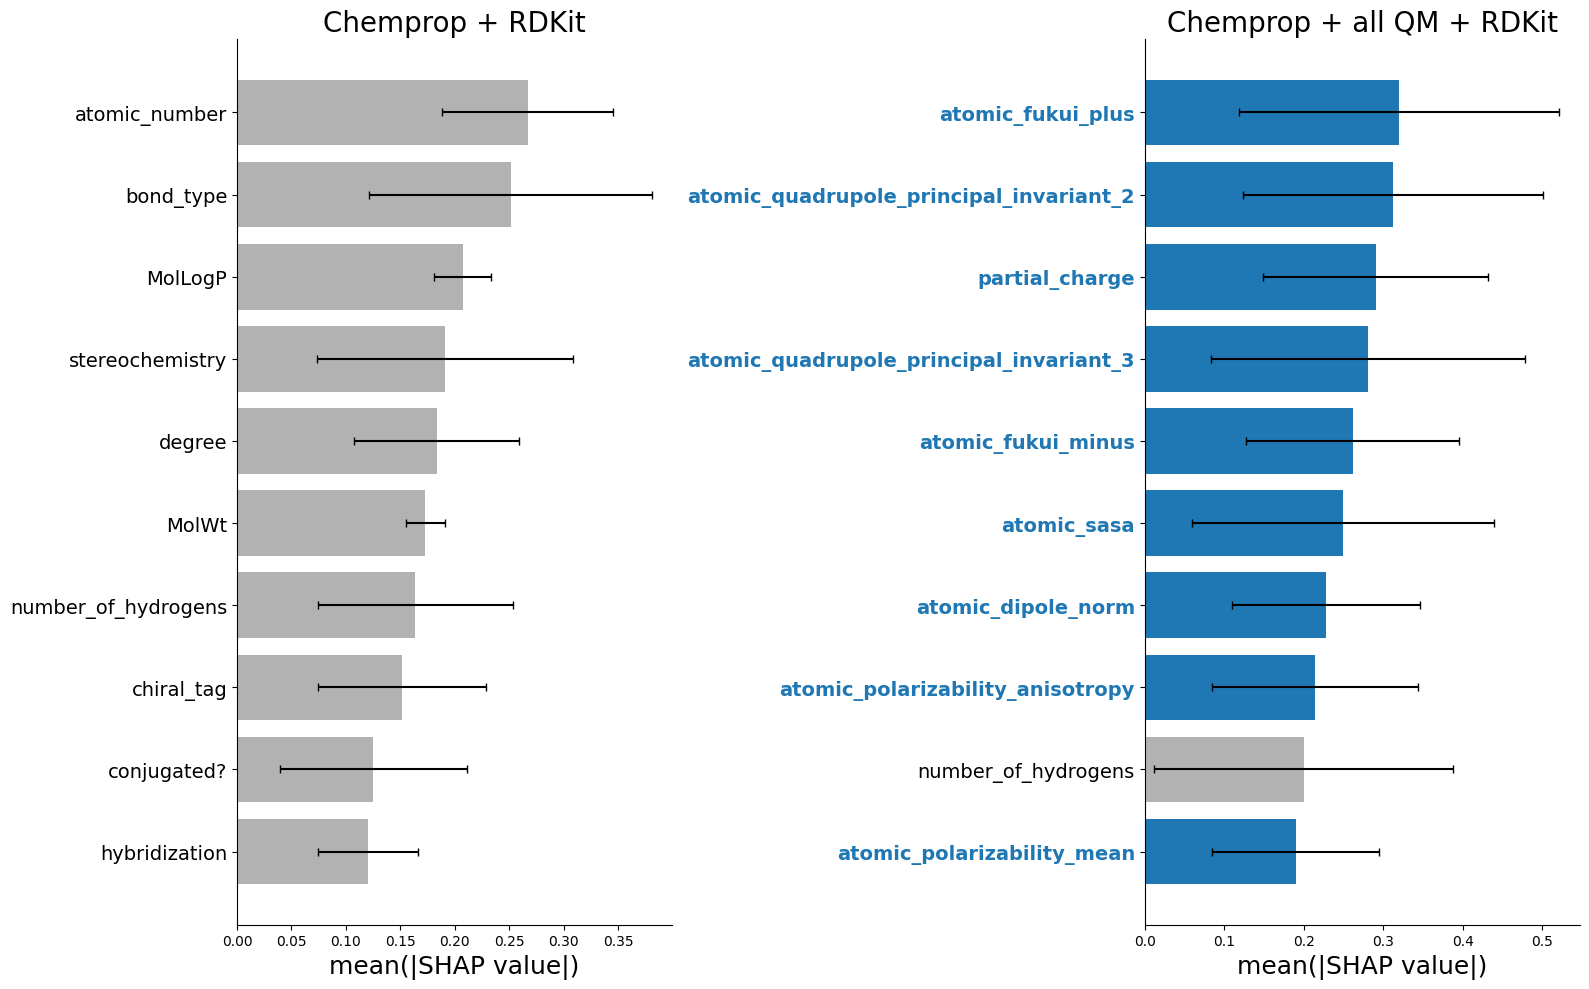

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# importance_baseline.plot(axes[0, 0], n_feat, shap=True, title="Baseline Chemprop")
importance_rdkit.plot(axes[0], n_feat, shap=True, title="Chemprop + RDKit")
# importance_mol.plot(axes[1, 0], n_feat, shap=True, title="Chemprop + mol QM + RDKit")
importance_full.plot(axes[1], n_feat, shap=True, title="Chemprop + all QM + RDKit")

plt.tight_layout()
# plt.savefig("shap_plots2.pdf", format="pdf")
plt.show()

In [9]:
groups = {
    "Atomic structure": [
        "atomic_number",
        "mass",
        "degree",
        "number_of_hydrogens",
        "hybridization",
        "formal_charge",
        "aromaticity",
        "chiral_tag",
    ],

    "Bond structure": [
        "bond_type",
        "in_ring?",
        "conjugated?",
        "stereochemistry",
    ],

    "Electrostatics": [
        "partial_charge",
        "atomic_dipole_norm",
    ],

    "Polarizability": [
        "atomic_polarizability_mean",
        "atomic_polarizability_anisotropy",
    ],

    "Reactivity": [
        "atomic_fukui_plus",
        "atomic_fukui_minus",
    ],

    "Geometry": [
        "atomic_sasa",
        "atomic_quadrupole_principal_invariant_2",
        "atomic_quadrupole_principal_invariant_3",
        "bond_length",
        "nuclear_repulsion",
        "bond_stiffness",
        "atomic_dipole_dipole_interaction",
    ],
}

In [10]:
def get_importance(feature_set: str, input_path: Path) -> tuple[pd.DataFrame, FeatureImportance]:
    shap_files = [file for file in input_path.glob("*SHAP*") if file.is_file()]

    combined_df = pd.DataFrame()

    for idx, file in enumerate(shap_files, start=1):
        with file.open("r") as f:
            data = json.load(f)
        
        df = pd.DataFrame(data["shap_values"], columns=data["feature_names"]).abs()

        if feature_set != "Chemprop + RDKit":
            df.drop("formal_charge", axis=1)

        new_df = pd.DataFrame()
        for key, vals in groups.items():
            try:
                new_df[key] = df[vals].mean(axis=1)
            except:
                continue

            df = df.drop(vals, axis=1)

        if len(df) > 0:
            new_df = pd.concat([new_df, df], axis=1)

        new_df = new_df.agg(["mean"], axis=0).T
        new_df = new_df.reset_index().rename({"index": "feature", "mean": "mean_abs_shap"}, axis=1)
        new_df.insert(0, "fold_id", idx)
        new_df.insert(1, "size", 1.0)

        combined_df = pd.concat(
            [combined_df, new_df]
        )
        
    importance = FeatureImportance(combined_df)

    importance.get_FI_from_shap(num_features=30)

    return combined_df, importance

In [13]:
input_paths = {
    # "Baseline Chemprop": Path(r"C:\Users\thibo\Downloads\hpc_results\3_chemprop_no_added_w_charge_rerun"),
    "Chemprop + RDKit": Path(r"C:\Users\thibo\Downloads\hpc_results\1_chemprop_w_rdkit_rerun"),
    # "Chemprop + mol QM + RDKit": Path(r"C:\Users\thibo\Downloads\hpc_results\1_chemprop_mol_feat_rerun"),
    "Chemprop + all QM + RDKit": Path(r"C:\Users\thibo\Downloads\hpc_results\1_chemprop_full_feat_rerun"),
}

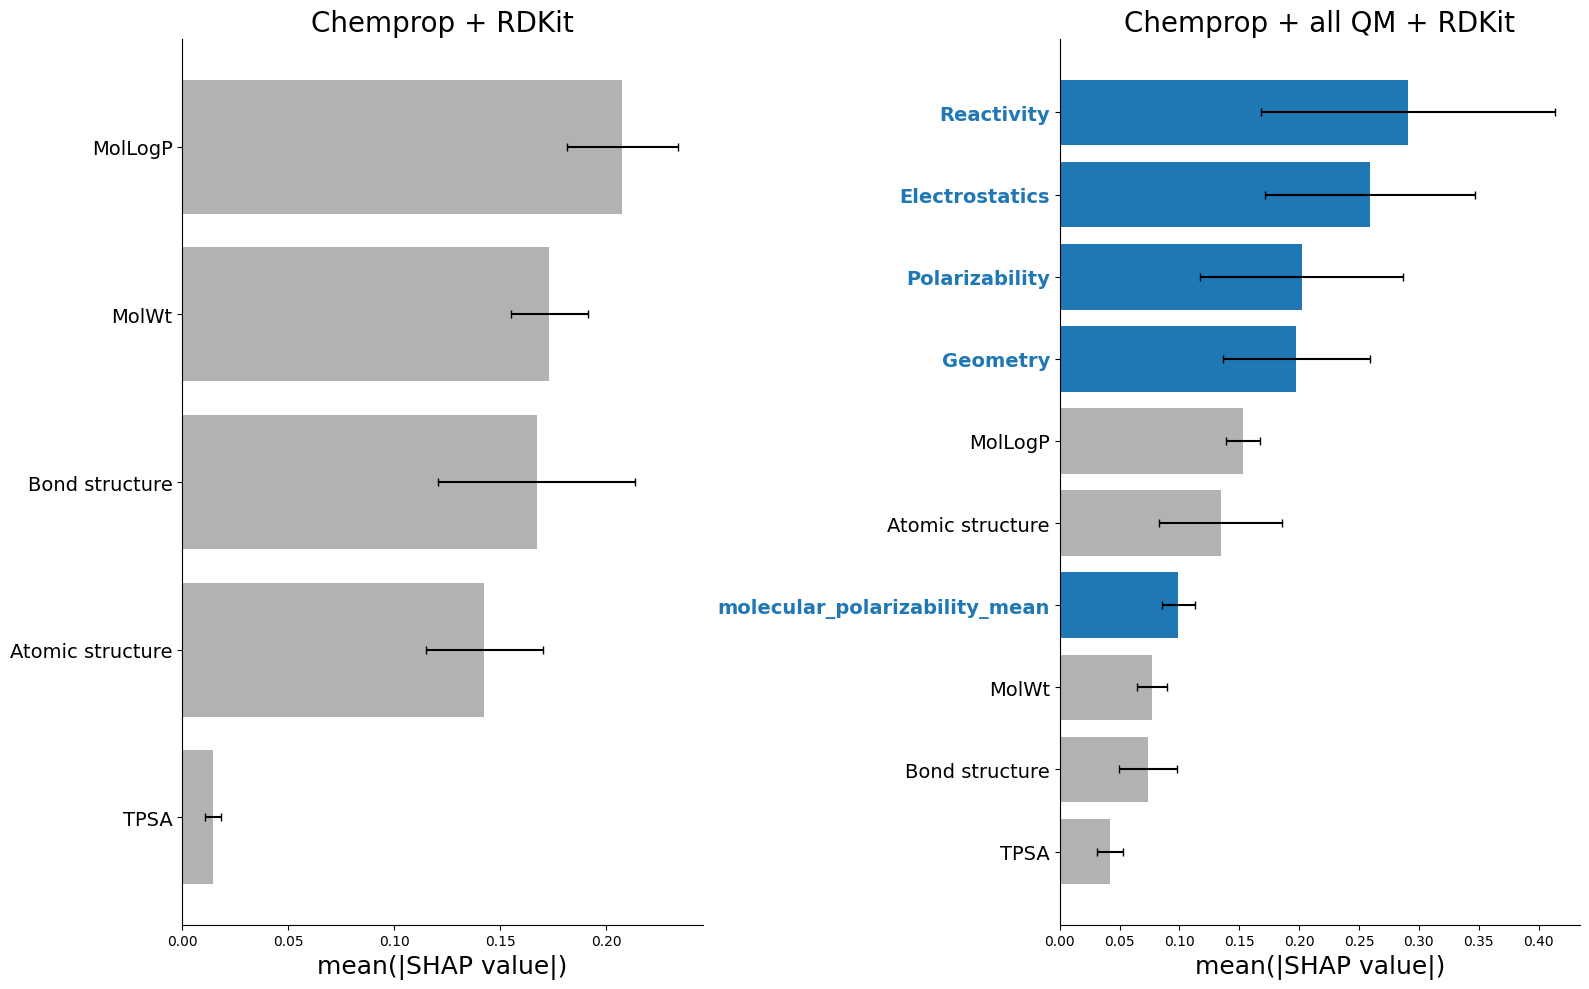

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

for idx, (key, input_path) in enumerate(input_paths.items()):
    # row, col = idx // 2, idx % 2

    df, importance = get_importance(key, input_path)

    importance.plot(axes[idx], 10, shap=True, title=key)

plt.tight_layout()
# plt.savefig("grouped_shap.pdf", format="pdf", bbox_inches='tight')
plt.show()

In [ ]:
groups1 = {
    "chemprop_atom": ["atomic_number", "degree", "formal_charge", "chiral_tag", "number_of_hydrogens", "hybridization", "aromaticity", "mass"],
    "chemprop_bond": ["bond_type", "conjugated?", "in_ring?", "stereochemistry"],
    "QM_atom": ["atomic_fukui_plus", "atomic_fukui_minus", "atomic_quadrupole_principal_invariant_2", "atomic_quadrupole_principal_invariant_3", "atomic_sasa", "partial_charge", "atomic_dipole_norm", "atomic_polarizability_mean", "atomic_polarizability_anisotropy"],
    "QM_bond": ["bond_stiffness", "atomic_dipole_dipole_interaction", "nuclear_repulsion", "bond_length"]
}

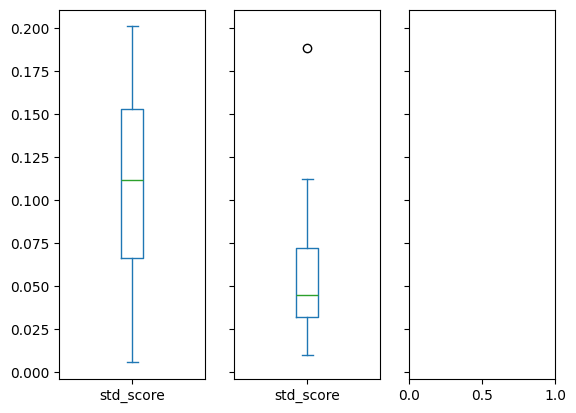

In [14]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True)

subset = fi_df_full.loc[~fi_df_full["feature"].isin(["MolWt", "TPSA", "MolLogP"])]

subset.loc[~fi_df_full["feature"].isin([*groups1["chemprop_atom"], *groups1["chemprop_bond"]]), "std_score"].plot.box(ax=ax1)
subset.loc[fi_df_full["feature"].isin([*groups1["chemprop_atom"], *groups1["chemprop_bond"]]), "std_score"].plot.box(ax=ax2)
# fi_df2.loc[~fi_df2["feature"].isin(["MolWt", "TPSA", "MolLogP"]), "std_score"].plot.box(ax=ax2)
# fi_df_base["std_score"].plot.box(ax=ax3)

plt.show()